# Keras TF 2.0 - Code Along Classification Project

Let's explore a classification task with Keras API for TF 2.0

## The Data

### Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry 
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 3 is Mean Radius, field
        13 is Radius SE, field 23 is Worst Radius.

        - class:
                - WDBC-Malignant
                - WDBC-Benign

    :Summary Statistics:

    ===================================== ====== ======
                                           Min    Max
    ===================================== ====== ======
    radius (mean):                        6.981  28.11
    texture (mean):                       9.71   39.28
    perimeter (mean):                     43.79  188.5
    area (mean):                          143.5  2501.0
    smoothness (mean):                    0.053  0.163
    compactness (mean):                   0.019  0.345
    concavity (mean):                     0.0    0.427
    concave points (mean):                0.0    0.201
    symmetry (mean):                      0.106  0.304
    fractal dimension (mean):             0.05   0.097
    radius (standard error):              0.112  2.873
    texture (standard error):             0.36   4.885
    perimeter (standard error):           0.757  21.98
    area (standard error):                6.802  542.2
    smoothness (standard error):          0.002  0.031
    compactness (standard error):         0.002  0.135
    concavity (standard error):           0.0    0.396
    concave points (standard error):      0.0    0.053
    symmetry (standard error):            0.008  0.079
    fractal dimension (standard error):   0.001  0.03
    radius (worst):                       7.93   36.04
    texture (worst):                      12.02  49.54
    perimeter (worst):                    50.41  251.2
    area (worst):                         185.2  4254.0
    smoothness (worst):                   0.071  0.223
    compactness (worst):                  0.027  1.058
    concavity (worst):                    0.0    1.252
    concave points (worst):               0.0    0.291
    symmetry (worst):                     0.156  0.664
    fractal dimension (worst):            0.055  0.208
    ===================================== ====== ======

    :Missing Attribute Values: None

    :Class Distribution: 212 - Malignant, 357 - Benign

    :Creator:  Dr. William H. Wolberg, W. Nick Street, Olvi L. Mangasarian

    :Donor: Nick Street

    :Date: November, 1995

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import joblib



In [2]:
cancer = load_breast_cancer()
df = pd.DataFrame(cancer['data'], columns=cancer['feature_names'])
df['benign_0__mal_1'] = cancer['target']

In [3]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## EDA

<Axes: xlabel='benign_0__mal_1', ylabel='count'>

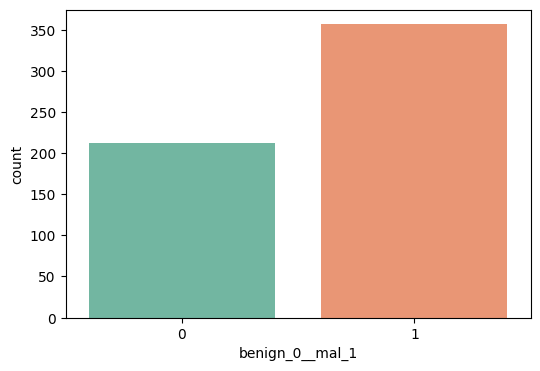

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='benign_0__mal_1', data=df, palette="Set2")

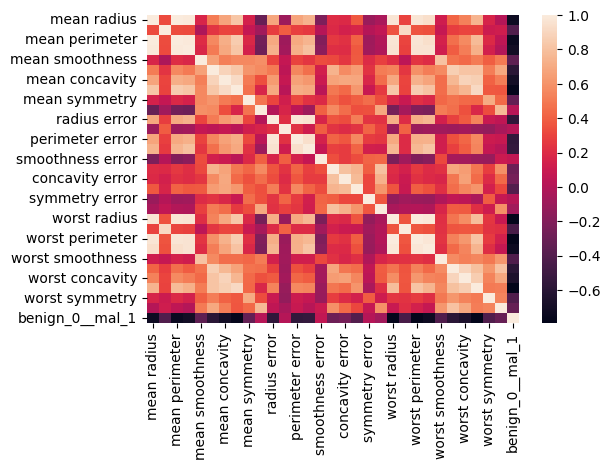

In [7]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr())
plt.show()

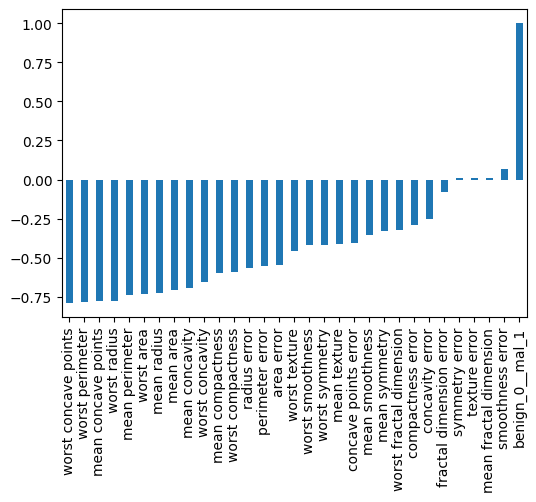

In [8]:
# Based on 'benign_0__mal_1'
corr = df.corr()['benign_0__mal_1'].sort_values()
plt.figure(figsize=(6,4))
corr.plot(kind='bar')
plt.show()

## Train Test Split

In [9]:
x = df.drop('benign_0__mal_1', axis=1)
y = df['benign_0__mal_1']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


## Scaling Data

In [15]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

joblib.dump(scaler, '../save_models/scaler_weights.pkl')
joblib.dump(x.columns.tolist(), '../save_models/feature_names.pkl')



['../save_models/feature_names.pkl']

## Creating the Model

    # For a binary classification problem
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
                  
    

In [16]:
model = Sequential()
model.add(Dense(30, activation='relu',input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])


## Training the Model 

### Example One: Choosing too many epochs and overfitting!

In [17]:
model.fit(x=X_train_scaled,y= y_train, epochs=900, batch_size=32, validation_data=(X_test_scaled, y_test))

Epoch 1/900
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6264 - loss: 0.6692 - val_accuracy: 0.7018 - val_loss: 0.6274
Epoch 2/900
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7456 - loss: 0.6252 - val_accuracy: 0.7544 - val_loss: 0.5834
Epoch 3/900
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8167 - loss: 0.5778 - val_accuracy: 0.9123 - val_loss: 0.5350
Epoch 4/900
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8665 - loss: 0.5412 - val_accuracy: 0.8860 - val_loss: 0.4868
Epoch 5/900
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8626 - loss: 0.4921 - val_accuracy: 0.9211 - val_loss: 0.4405
Epoch 6/900
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8908 - loss: 0.4495 - val_accuracy: 0.9211 - val_loss: 0.3959
Epoch 7/900
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8871 - loss: 0.4061 - val_accuracy: 0.9123 - val_loss: 0.3596
Epoch 8/900
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9003 - loss: 0.3688 - val_accuracy: 0.9298 - 

In [18]:
model.history.history

{'accuracy': [0.6571428775787354,
  0.7626373767852783,
  0.8131868243217468,
  0.8703296780586243,
  0.8637362718582153,
  0.8835164904594421,
  0.8901098966598511,
  0.894505500793457,
  0.898901104927063,
  0.901098906993866,
  0.9274725317955017,
  0.9142857193946838,
  0.9120879173278809,
  0.9076923131942749,
  0.9252747297286987,
  0.9252747297286987,
  0.9230769276618958,
  0.9318681359291077,
  0.9318681359291077,
  0.9296703338623047,
  0.9494505524635315,
  0.9406593441963196,
  0.9494505524635315,
  0.9406593441963196,
  0.9450549483299255,
  0.9406593441963196,
  0.9516483545303345,
  0.9494505524635315,
  0.9582417607307434,
  0.9648351669311523,
  0.9560439586639404,
  0.9604395627975464,
  0.9560439586639404,
  0.9626373648643494,
  0.9582417607307434,
  0.9692307710647583,
  0.9604395627975464,
  0.9714285731315613,
  0.9692307710647583,
  0.9736263751983643,
  0.9692307710647583,
  0.9780219793319702,
  0.9780219793319702,
  0.9692307710647583,
  0.9758241772651672,
 

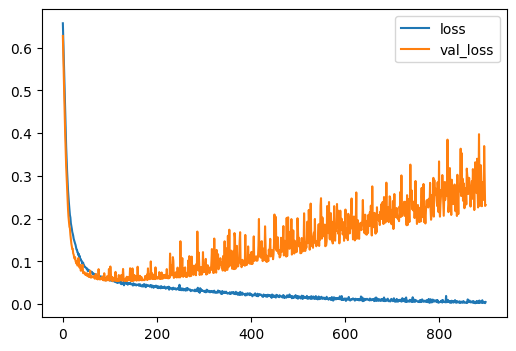

In [19]:
# model_loss
plt.figure(figsize=(6,4))

plt.plot(model.history.history['loss'], label='loss')
plt.plot(model.history.history['val_loss'], label='val_loss')

plt.legend()
plt.show()

## Example Two: Early Stopping

We obviously trained too much! Let's use early stopping to track the val_loss and stop training once it begins increasing too much!

Stop training when a monitored quantity has stopped improving.

    Arguments:
        monitor: Quantity to be monitored.
        min_delta: Minimum change in the monitored quantity
            to qualify as an improvement, i.e. an absolute
            change of less than min_delta, will count as no
            improvement.
        patience: Number of epochs with no improvement
            after which training will be stopped.
        verbose: verbosity mode.
        mode: One of `{"auto", "min", "max"}`. In `min` mode,
            training will stop when the quantity
            monitored has stopped decreasing; in `max`
            mode it will stop when the quantity
            monitored has stopped increasing; in `auto`
            mode, the direction is automatically inferred
            from the name of the monitored quantity.

In [20]:
model1 = Sequential()
model1.add(Dense(30, activation='relu',input_shape=(X_train_scaled.shape[1],)))
model1.add(Dense(15, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))
model1.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])


In [21]:
early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    patience=10
)

In [22]:
model1.fit(
    x=X_train_scaled,
    y=y_train,
    epochs=600,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop]
)


Epoch 1/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6357 - loss: 0.6863 - val_accuracy: 0.6754 - val_loss: 0.6556
Epoch 2/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7125 - loss: 0.6547 - val_accuracy: 0.8421 - val_loss: 0.6239
Epoch 3/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8452 - loss: 0.6229 - val_accuracy: 0.8246 - val_loss: 0.5922
Epoch 4/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8312 - loss: 0.5927 - val_accuracy: 0.8947 - val_loss: 0.5536
Epoch 5/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8615 - loss: 0.5518 - val_accuracy: 0.8860 - val_loss: 0.5102
Epoch 6/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8526 - loss: 0.5289 - val_accuracy: 0.8860 - val_loss: 0.4701
Epoch 7/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8812 - loss: 0.4675 - val_accuracy: 0.9211 - val_loss: 0.4277
Epoch 8/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9253 - loss: 0.4308 - val_accuracy: 0.9298 - 

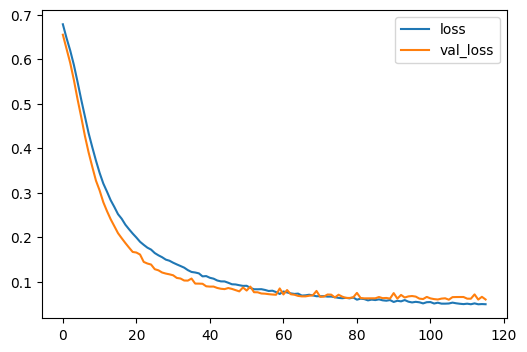

In [23]:
# model_loss
plt.figure(figsize=(6,4))

plt.plot(model1.history.history['loss'], label='loss')
plt.plot(model1.history.history['val_loss'], label='val_loss')

plt.legend()
plt.show()

## Example Three: Adding in DropOut Layers

In [24]:
model2 = Sequential()

model2.add(Dense(30, activation='relu',input_shape=(X_train_scaled.shape[1],),))
model2.add(Dropout(0.2))
model2.add(Dense(15, activation='relu'))
model2.add(Dropout(0.2))

model2.add(Dense(1, activation='sigmoid'))
model2.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])


In [25]:
model2.fit(
    x=X_train_scaled,
    y=y_train,
    epochs=600,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop]
)


Epoch 1/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4810 - loss: 0.6730 - val_accuracy: 0.7632 - val_loss: 0.6416
Epoch 2/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7053 - loss: 0.6465 - val_accuracy: 0.8684 - val_loss: 0.6168
Epoch 3/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7935 - loss: 0.6157 - val_accuracy: 0.8596 - val_loss: 0.5812
Epoch 4/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8198 - loss: 0.5947 - val_accuracy: 0.9035 - val_loss: 0.5487
Epoch 5/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8246 - loss: 0.5740 - val_accuracy: 0.9123 - val_loss: 0.5203
Epoch 6/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8674 - loss: 0.5284 - val_accuracy: 0.9298 - val_loss: 0.4878
Epoch 7/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8414 - loss: 0.5211 - val_accuracy: 0.9386 - val_loss: 0.4479
Epoch 8/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8843 - loss: 0.4707 - val_accuracy: 0.9386 - 

In [26]:
model2.history.history

{'accuracy': [0.5274725556373596,
  0.7252747416496277,
  0.8043956160545349,
  0.8351648449897766,
  0.8329670429229736,
  0.8549450635910034,
  0.8637362718582153,
  0.8901098966598511,
  0.8769230842590332,
  0.8879120945930481,
  0.901098906993866,
  0.8879120945930481,
  0.8747252821922302,
  0.903296709060669,
  0.894505500793457,
  0.9142857193946838,
  0.892307698726654,
  0.9076923131942749,
  0.9076923131942749,
  0.898901104927063,
  0.9076923131942749,
  0.903296709060669,
  0.9098901152610779,
  0.9142857193946838,
  0.9296703338623047,
  0.9120879173278809,
  0.9296703338623047,
  0.9186813235282898,
  0.9142857193946838,
  0.9340659379959106,
  0.9296703338623047,
  0.9340659379959106,
  0.9384615421295166,
  0.9362637400627136,
  0.9428571462631226,
  0.9296703338623047,
  0.9406593441963196,
  0.9494505524635315,
  0.9428571462631226,
  0.9362637400627136,
  0.9494505524635315,
  0.9406593441963196,
  0.9494505524635315,
  0.9560439586639404,
  0.9472527503967285,
  0.

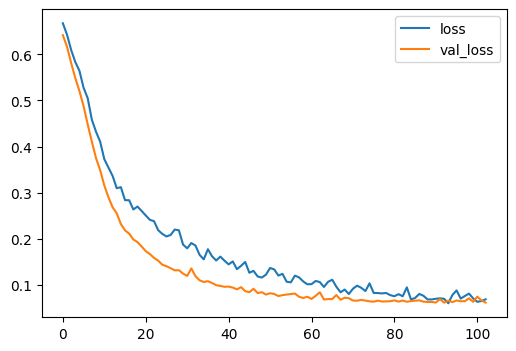

In [27]:
# model_loss
plt.figure(figsize=(6,4))

plt.plot(model2.history.history['loss'], label='loss')
plt.plot(model2.history.history['val_loss'], label='val_loss')

plt.legend()
plt.show()

# Model Evaluation

In [28]:
from sklearn.metrics import classification_report,confusion_matrix

In [29]:
# التنبؤ على بيانات الاختبار
y_pred_proba = model2.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# حساب الدقة
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("="*50)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Accuracy: 0.9649 (96.49%)


In [30]:
print("Classification Report")
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



In [31]:
confusion_matrix(y_test, y_pred)

array([[41,  2],
       [ 2, 69]])

## save the model

In [32]:

model2.save('../save_models/cancer_model.h5')
